<a href="https://colab.research.google.com/github/najafalinajaf449-hue/machine-learning/blob/main/LAB%204%20ML%20Improving%20and%20Comparing%20Machine%20Learning%20Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LAB 4 ML Improving and Comparing Machine Learning Models**



Name: Najaf Ali
Student ID: 023-24-0263
Section: CS V

GitHub Profile:https://github.com/najafalinajaf449-hue/machine-learning

Kaggle Profile: https://www.kaggle.com/najaf2ali
Dataset: Telco Customer Churn Dataset

In [17]:
#TASK 1: RELOADED LAB2 clean dataset with same train test plit as lab 3

import pandas as pd
from sklearn.model_selection import train_test_split

df_churn = pd.read_csv("clean_churn.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df_churn.shape)

y = df_churn["Churn"].map({
    "Yes": 1,
    "No": 0
})

x = df_churn.drop("Churn", axis=1)

categorical_cols = x.select_dtypes(
    include=["object"]
).columns

print("\nCategorical columns:")
print(list(categorical_cols))

x_encoded = pd.get_dummies(
    x,
    columns=categorical_cols,
    drop_first=False
)

X_train, X_test, y_train, y_test = train_test_split(
    x_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nEncoded feature shape:", x_encoded.shape)

print("\nTraining data shape:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data shape:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)



Dataset loaded successfully!
Dataset shape: (7043, 20)

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Encoded feature shape: (7043, 45)

Training data shape:
X_train: (5634, 45)
y_train: (5634,)

Testing data shape:
X_test: (1409, 45)
y_test: (1409,)


In [18]:
#TASK2 retrain the best decision tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Decision Tree Results
Accuracy : 0.7984386089425124
Precision: 0.6347305389221557
Recall   : 0.5668449197860963
F1-score : 0.5988700564971752


In [19]:
#TASK 3 TRAIN A RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


**TASK 4 EXPLAIN RANDOM FOREST**
Random Forest can perform better than a single Decision Tree because it uses multiple trees to make a prediction instead of depending on just one tree. Each tree looks at different samples and features, and their results are combined for the final prediction. This helps reduce overfitting and makes the model more reliable. Because of this, Random Forest can usually give more stable and accurate results on new data.

Random Forest Results
Accuracy : 0.7856635911994322
Precision: 0.6232876712328768
Recall   : 0.48663101604278075
F1-score : 0.5465465465465466


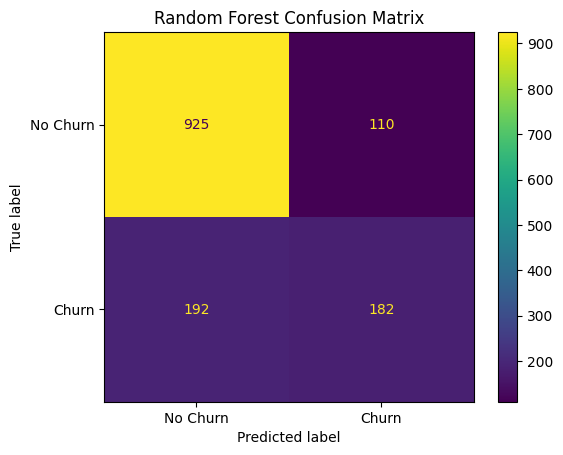

In [20]:
#TASK 5 EVALUATE RANDOM FOREST
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1-score :", f1_rf)

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [21]:
#TASK 6 RANDO FOREST VS DECISION TREE
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [accuracy, accuracy_rf],
    "Precision": [precision, precision_rf],
    "Recall": [recall, recall_rf],
    "F1-score": [f1, f1_rf]
})

print(comparison)

           Model  Accuracy  Precision    Recall  F1-score
0  Decision Tree  0.798439   0.634731  0.566845  0.598870
1  Random Forest  0.785664   0.623288  0.486631  0.546547


**TASK 7 INTERPRET THE COMPARIOSON AND DISCUSS CLAS IMBALANCE**
> The Decision Tree performed better than the Random Forest in our results. Since the dataset has more non-churn customers, accuracy alone is not enough. Precision, Recall, and F1-score are also important. Overall, the Decision Tree gave better results for this dataset.


In [22]:
#TASK 8 , 5 FOLD CROSS VALIDATION
from sklearn.model_selection import cross_val_score

dt_scores = cross_val_score(
    dt_model,
    x_encoded,
    y,
    cv=5,
    scoring="f1"
)

rf_scores = cross_val_score(
    rf_model,
    x_encoded,
    y,
    cv=5,
    scoring="f1"
)

print("Decision Tree F1 Scores:")
print(dt_scores)

print("\nDecision Tree Mean F1:", dt_scores.mean())
print("Decision Tree Std:", dt_scores.std())

print("\nRandom Forest F1 Scores:")
print(rf_scores)

print("\nRandom Forest Mean F1:", rf_scores.mean())
print("Random Forest Std:", rf_scores.std())

Decision Tree F1 Scores:
[0.61246612 0.62382865 0.59259259 0.5907781  0.57720058]

Decision Tree Mean F1: 0.5993732080724318
Decision Tree Std: 0.016619092795368173

Random Forest F1 Scores:
[0.56752656 0.54545455 0.50822123 0.5482866  0.56183206]

Random Forest Mean F1: 0.5462641983963167
Random Forest Std: 0.020719361030532266


**TASK 9**
The Decision Tree has a higher mean F1-score than the Random Forest, so it performed better overall. The standard deviation is small for both models, which means their results were fairly consistent across the 5 folds.

In [23]:
#TASK 10 HYPERPARATER TUNING
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8, None],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1-score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 100}

Best CV F1-score:
0.5780751898390991


In [24]:
#TASK 11 REPORT BEST PARAMTER AND CV SCORE
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1-score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation F1-score:
0.5780751898390991


In [25]:
#TASK 12 EVALUATE TUNED RANDOM FOREST
best_rf = grid_search.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)

accuracy_best = accuracy_score(y_test, y_pred_best_rf)
precision_best = precision_score(y_test, y_pred_best_rf)
recall_best = recall_score(y_test, y_pred_best_rf)
f1_best = f1_score(y_test, y_pred_best_rf)

print("Tuned Random Forest Results")
print("Accuracy :", accuracy_best)
print("Precision:", precision_best)
print("Recall   :", recall_best)
print("F1-score :", f1_best)

Tuned Random Forest Results
Accuracy : 0.8041163946061036
Precision: 0.677536231884058
Recall   : 0.5
F1-score : 0.5753846153846154


In [26]:
#TASK 13 FINAL MODE COMPARISON
final_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_rf,
        accuracy_best
    ],
    "Precision": [
        precision,
        precision_rf,
        precision_best
    ],
    "Recall": [
        recall,
        recall_rf,
        recall_best
    ],
    "F1-score": [
        f1,
        f1_rf,
        f1_best
    ]
})

final_comparison = final_comparison.round(4)

print(final_comparison)

                 Model  Accuracy  Precision  Recall  F1-score
0        Decision Tree    0.7984     0.6347  0.5668    0.5989
1        Random Forest    0.7857     0.6233  0.4866    0.5465
2  Tuned Random Forest    0.8041     0.6775  0.5000    0.5754


**TASK 14**
I would choose the Decision Tree as the final model because it has the highest F1-score and recall among the three models. Although the Tuned Random Forest has slightly higher accuracy, the Decision Tree is better at identifying customers who may churn.

In [27]:
#TASK 15 FEATURE IMPORTANCE
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                           Feature  Importance
36         Contract_Month-to-month    0.513973
16     InternetService_Fiber optic    0.163262
1                           tenure    0.156717
3                     TotalCharges    0.036499
2                   MonthlyCharges    0.035922
43  PaymentMethod_Electronic check    0.027931
27                  TechSupport_No    0.026824
37               Contract_One year    0.009218
21                 OnlineBackup_No    0.009198
18               OnlineSecurity_No    0.008620


In [28]:
#TASK 16 CREATE SUMBIION.CSV FILE
submission = pd.DataFrame({
    "Churn": y_pred_dt
})

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")
print(submission.head())

submission.csv created successfully!
   Churn
0      0
1      1
2      0
3      1
4      0


**TASK 17**

In this lab, I trained and compared Decision Tree and Random Forest models for customer churn prediction. The Decision Tree performed better overall based on its F1-score and recall. I also used cross-validation and hyperparameter tuning to improve the Random Forest model. The tuned Random Forest achieved better accuracy and precision, but its F1-score was still lower than the Decision Tree. Therefore, I selected the Decision Tree as the final model for this dataset.

**TASK 18**

In the future, the model could be improved by trying more machine learning algorithms and tuning more hyperparameters. Class imbalance could also be handled using techniques such as class weights or resampling. More feature engineering could help the model understand the customer data better. Using a larger range of models and comparing their results could also improve the final prediction performance.